In [1]:
# Libraries for loading models and working with data
import tensorflow as tf
import numpy as np
import pandas as pd

# Libraries for visualizations
import matplotlib.pyplot as plt
import seaborn as sns

# Evaluation metrics
from sklearn.metrics import classification_report, confusion_matrix

# Path handling
from pathlib import Path

In [2]:
# Dataset paths
test_dir = Path("../data/Testing")

# Image settings
IMG_SIZE = (224, 224)
BATCH_SIZE = 8

In [3]:
# Load test dataset without shuffling so predictions match true labels
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = test_ds.class_names
print(class_names)

Found 554 files belonging to 4 classes.
['glioma', 'meningioma', 'notumor', 'pituitary']


In [4]:
# Baseline CNN was trained using simple 0-1 normalization
normalization_layer = tf.keras.layers.Rescaling(1./255)

test_ds_cnn = test_ds.map(lambda x, y: (normalization_layer(x), y))

In [5]:
# MobileNetV2 requires its own preprocessing function
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess

test_ds_mobilenet = test_ds.map(lambda x, y: (mobilenet_preprocess(x), y))

In [17]:
# EfficientNetB0 in Keras includes preprocessing internally,
# so we use the original test dataset directly.
test_ds_efficientnet = test_ds

In [18]:
# Load trained models
baseline_model = tf.keras.models.load_model("../models/baseline_cnn.keras")
mobilenet_model = tf.keras.models.load_model("../models/mobilenetv2_model.keras")
efficientnet_model = tf.keras.models.load_model("../models/efficientnetb0_model.keras")


In [19]:
# Evaluate each model on the correct version of the test dataset
baseline_loss, baseline_acc = baseline_model.evaluate(test_ds_cnn)
mobilenet_loss, mobilenet_acc = mobilenet_model.evaluate(test_ds_mobilenet)
efficientnet_loss, efficientnet_acc = efficientnet_model.evaluate(test_ds_efficientnet)

results_df = pd.DataFrame({
    "Model": ["Baseline CNN", "MobileNetV2", "EfficientNetB0"],
    "Test Loss": [baseline_loss, mobilenet_loss, efficientnet_loss],
    "Test Accuracy": [baseline_acc, mobilenet_acc, efficientnet_acc]
})

results_df

70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.9170 - loss: 0.2952
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - accuracy: 0.8736 - loss: 0.3905
70/70 ━━━━━━━━━━━━━━━━━━━━ 6s 69ms/step - accuracy: 0.8592 - loss: 0.3915


,Model,Test Loss,Test Accuracy
0,Baseline CNN,0.295204,0.916968
1,MobileNetV2,0.390525,0.873646
2,EfficientNetB0,0.391546,0.859206


In [20]:
# Save results table for final report
results_df.to_csv("../figures/model_comparison_results.csv", index=False)

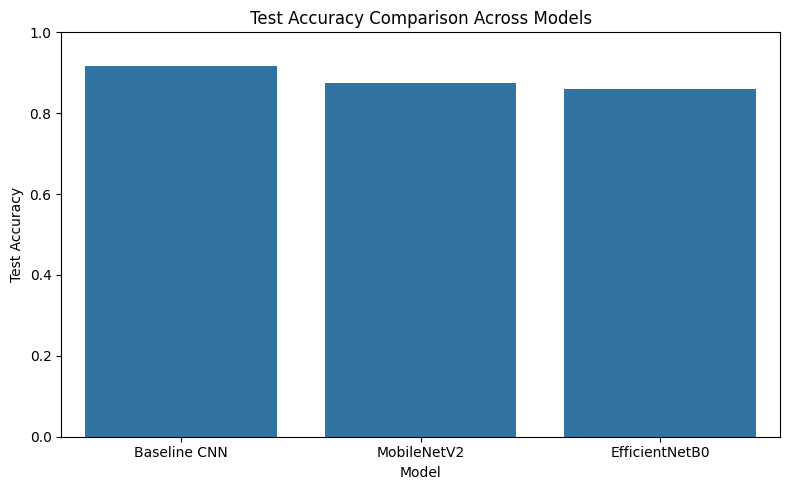

In [21]:
# Plot test accuracy comparison across models
plt.figure(figsize=(8, 5))

sns.barplot(
    data=results_df,
    x="Model",
    y="Test Accuracy"
)

plt.title("Test Accuracy Comparison Across Models")
plt.xlabel("Model")
plt.ylabel("Test Accuracy")
plt.ylim(0, 1)

plt.tight_layout()
plt.savefig("../figures/model_accuracy_comparison.png", dpi=300)
plt.show()

In [22]:
# Collect true labels from test dataset
y_true = []

for images, labels in test_ds:
    y_true.extend(labels.numpy())

y_true = np.array(y_true)

In [23]:
# Generate predictions using the best-performing baseline CNN
y_pred_probs = baseline_model.predict(test_ds_cnn)
y_pred = np.argmax(y_pred_probs, axis=1)

70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step


In [24]:
# Print precision, recall, and F1-score for each tumor class
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names
)

print(report)

              precision    recall  f1-score   support

      glioma       0.36      0.71      0.48         7
  meningioma       0.87      0.84      0.86       147
     notumor       0.00      0.00      0.00         0
   pituitary       0.99      0.95      0.97       400

    accuracy                           0.92       554
   macro avg       0.55      0.63      0.58       554
weighted avg       0.95      0.92      0.93       554



/Users/abhichalla/Projects/brain-mri-classification/venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/abhichalla/Projects/brain-mri-classification/venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/abhichalla/Projects/brain-mri-classification/venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.


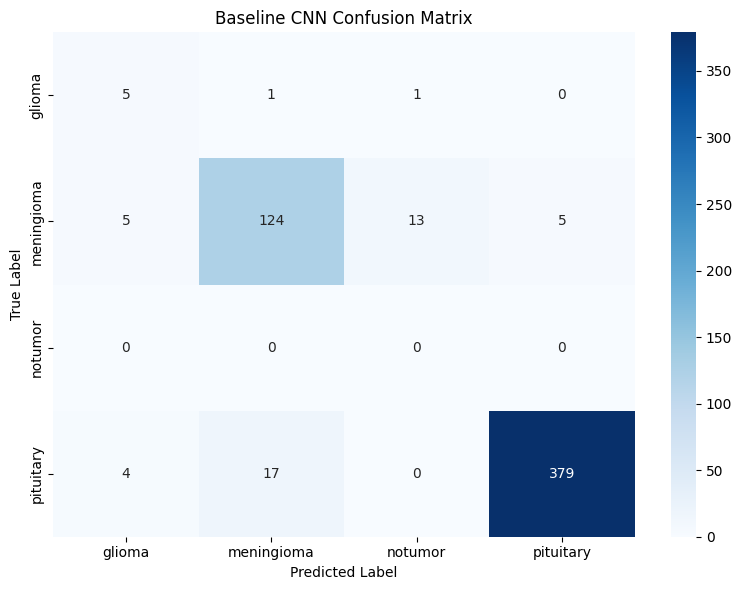

In [25]:
# Create confusion matrix for baseline CNN
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Baseline CNN Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()
plt.savefig("../figures/baseline_confusion_matrix.png", dpi=300)
plt.show()

## Model Evaluation Summary

This notebook compared the baseline CNN, MobileNetV2, and EfficientNetB0 models on the held-out testing set. The baseline CNN achieved the highest test accuracy, outperforming both frozen transfer learning models. This suggests that, for this dataset, a custom CNN trained directly on MRI images may learn task-specific features more effectively than pretrained ImageNet feature extractors without additional fine-tuning. The confusion matrix and classification report provide class-level insight into the model's strengths and errors.
